# QINR-QGAN — Advanced Evaluation Notebook
This notebook evaluates the QINR-QGAN's generated Mg-Mn-O crystal structures using three metrics:

| # | Metric | What it measures |
|---|--------|-----------------|
| 1 | **Structural Similarity (SSIM)** | How closely the global 3D geometry of generated crystals resembles the training data |
| 2 | **Structural Dissimilarity (StructureMatcher)** | Whether the model creates genuinely *new* structures vs. copies |
| 3 | **Energy Above Convex Hull (E_hull)** | Thermodynamic stability — requires a Materials Project API key |
| 4 | **Training Loss Curve** | Generator / Critic / Physics loss over epochs |

> **Note:** E_hull is skipped unless you set the `MP_API_KEY` environment variable (free at materialsproject.org).

## 0. Imports & Setup

In [13]:
import os, sys, pickle, glob, random, warnings
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
warnings.filterwarnings('ignore')

# ── Path setup ────────────────────────────────────────────────────
sys.path.insert(0, os.getcwd())
sys.path.insert(0, os.path.join(os.getcwd(), 'datasets'))

from models.QINR_Crystal import PQWGAN_CC_Crystal
from view_atoms_mgmno import view_atoms

# ── Optional heavy deps ──────────────────────────────────────────
try:
    from skimage.metrics import structural_similarity as ssim
    SKIMAGE_OK = True
    print("✅ scikit-image loaded — SSIM enabled")
except ImportError:
    SKIMAGE_OK = False
    print("❌ scikit-image not found  →  pip install scikit-image")

try:
    from pymatgen.io.ase import AseAtomsAdaptor
    from pymatgen.analysis.structure_matcher import StructureMatcher
    PYMATGEN_OK = True
    print("✅ pymatgen loaded — StructureMatcher enabled")
except ImportError:
    PYMATGEN_OK = False
    print("❌ pymatgen not found  →  pip install pymatgen")

try:
    from chgnet.model.dynamics import StructOptimizer
    from mp_api.client import MPRester
    from pymatgen.analysis.phase_diagram import PhaseDiagram
    EHULL_OK = True
    print("✅ chgnet + mp-api loaded — E_hull enabled")
except ImportError:
    EHULL_OK = False
    print("⚠️  chgnet/mp-api not found  →  pip install chgnet mp-api   (E_hull will be skipped)")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n🖥  Device: {device}")

✅ scikit-image loaded — SSIM enabled
✅ pymatgen loaded — StructureMatcher enabled
✅ chgnet + mp-api loaded — E_hull enabled

🖥  Device: cuda


## 1. Load Model & Generate Crystals
We load the latest checkpoint and generate **50 crystals** for evaluation.

In [14]:
NUM_SAMPLES = 50
Z_DIM, LABEL_DIM, DATA_DIM = 16, 28, 90

# ── Dataset ───────────────────────────────────────────────────────
DATASET = "datasets/mgmno_100.pickle"
with open(DATASET, 'rb') as f:
    raw_data = pickle.load(f)

labels, real_atoms_list = [], []
ref_indices = random.sample(range(len(raw_data)), min(100, len(raw_data)))
for idx in ref_indices:
    c, l = raw_data[idx]
    if len(labels) < NUM_SAMPLES:
        labels.append(l.flatten())
    atoms, _ = view_atoms(c.flatten(), view=False)
    real_atoms_list.append(atoms)

while len(labels) < NUM_SAMPLES:
    labels.append(labels[0])
labels_t = torch.tensor(np.array(labels, dtype=np.float32)).to(device)

# ── Generator ─────────────────────────────────────────────────────
ckpts = sorted(glob.glob("./results_crystal_qgan/checkpoint_*.pt"), key=os.path.getmtime)
assert ckpts, "No checkpoints found! Train the model first."
CKPT = ckpts[-1]
print(f"📂 Loading checkpoint: {CKPT}")

gan = PQWGAN_CC_Crystal(Z_DIM+LABEL_DIM, DATA_DIM, DATA_DIM+LABEL_DIM,
                         hidden_features=6, hidden_layers=2,
                         spectrum_layer=2, use_noise=0.0)
generator = gan.generator.to(device)
ckpt_data = torch.load(CKPT, map_location=device)
generator.load_state_dict(ckpt_data['generator'])
generator.eval()

# ── Generate ─────────────────────────────────────────────────────
with torch.no_grad():
    z = torch.randn(NUM_SAMPLES, Z_DIM).to(device)
    fake_flat = generator(torch.cat([z, labels_t], dim=1)).cpu().numpy()

generated_atoms = []
for img in fake_flat:
    atoms, _ = view_atoms(img, view=False)
    generated_atoms.append(atoms)

print(f"✅ Generated {len(generated_atoms)} crystal structures for evaluation.")

📂 Loading checkpoint: ./results_crystal_qgan\checkpoint_90.pt
✅ Generated 50 crystal structures for evaluation.


## 2. Structural Similarity Index Measure (SSIM)
**What it is:** SSIM is borrowed from image processing. Here we represent each crystal as a **30×30 interatomic distance matrix** (every atom's distance to every other atom). We then compute SSIM between the distance matrix of a generated crystal and a real one.

**How to read the result:**  
- `SSIM = 1.0` → Perfect structural match  
- `SSIM = 0.0` → No similarity  
- Classical GAN benchmark on Mg-Mn-O: typically **0.55–0.70** on similar architectures

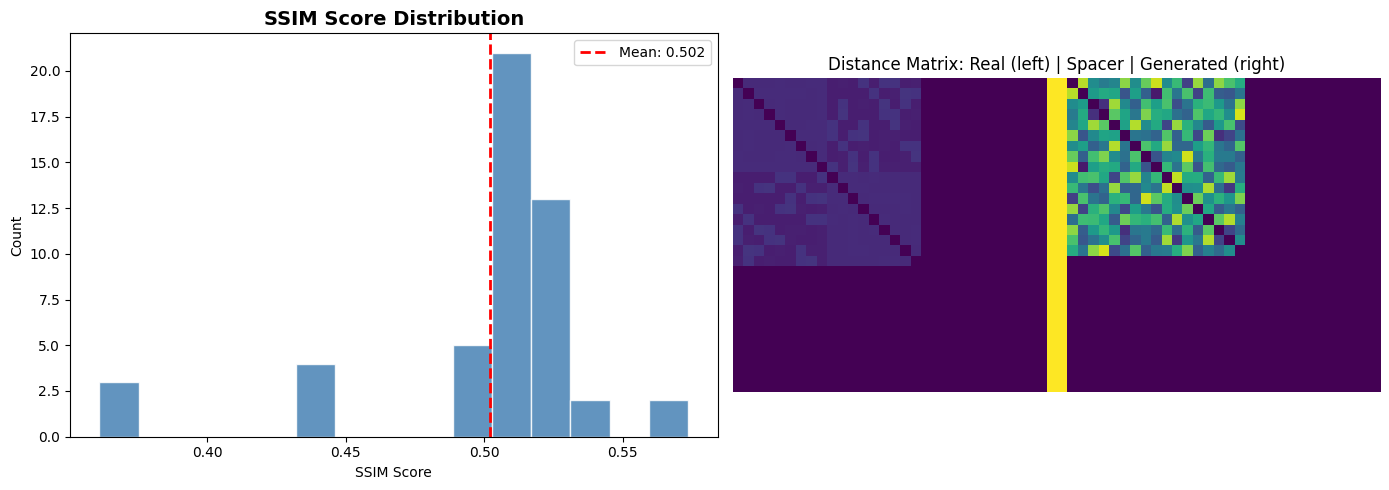


📊 Average SSIM Score : 0.5020
   Min SSIM           : 0.3610
   Max SSIM           : 0.5736

💡 Interpretation: Higher = generated structure patterns more closely match the real training data.


In [15]:
def dist_matrix(atoms):
    d = atoms.get_all_distances(mic=True)
    mat = np.zeros((30, 30))
    n = min(30, d.shape[0])
    mat[:n, :n] = d[:n, :n]
    return mat

if SKIMAGE_OK:
    ssim_scores = []
    for g_atom in generated_atoms:
        g_mat = dist_matrix(g_atom)
        r_mat = dist_matrix(random.choice(real_atoms_list))
        score = ssim(g_mat, r_mat, data_range=25.0)
        ssim_scores.append(score)

    avg_ssim = np.mean(ssim_scores)

    # ── Plot ─────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].hist(ssim_scores, bins=15, color='steelblue', edgecolor='white', alpha=0.85)
    axes[0].axvline(avg_ssim, color='red', linestyle='--', linewidth=2, label=f'Mean: {avg_ssim:.3f}')
    axes[0].set_title('SSIM Score Distribution', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('SSIM Score')
    axes[0].set_ylabel('Count')
    axes[0].legend()

    # Show one example distance matrix comparison
    g_ex = dist_matrix(generated_atoms[0])
    r_ex = dist_matrix(real_atoms_list[0])
    axes[1].imshow(np.hstack([r_ex, np.ones((30,2))*25, g_ex]), cmap='viridis', vmin=0, vmax=25)
    axes[1].set_title('Distance Matrix: Real (left) | Spacer | Generated (right)', fontsize=12)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    print(f"\n📊 Average SSIM Score : {avg_ssim:.4f}")
    print(f"   Min SSIM           : {min(ssim_scores):.4f}")
    print(f"   Max SSIM           : {max(ssim_scores):.4f}")
    print("\n💡 Interpretation: Higher = generated structure patterns more closely match the real training data.")
else:
    print("SSIM skipped — install scikit-image to enable this metric.")

## 3. Structural Dissimilarity (Pymatgen StructureMatcher)
**What it is:** Pymatgen's `StructureMatcher` compares full 3D crystal structures — including lattice parameters and atomic positions — to determine if two crystals are the same phase (allowing for small distortions and element substitutions).

**How to read the result:**  
- `0 matches` → The QGAN generated completely **new** structures not in the training set (high novelty!)  
- `match_count > 0` → Some generated structures are structurally similar to known training samples  
- **RMS displacement** measures how far the atoms are from their nearest-match positions in Å

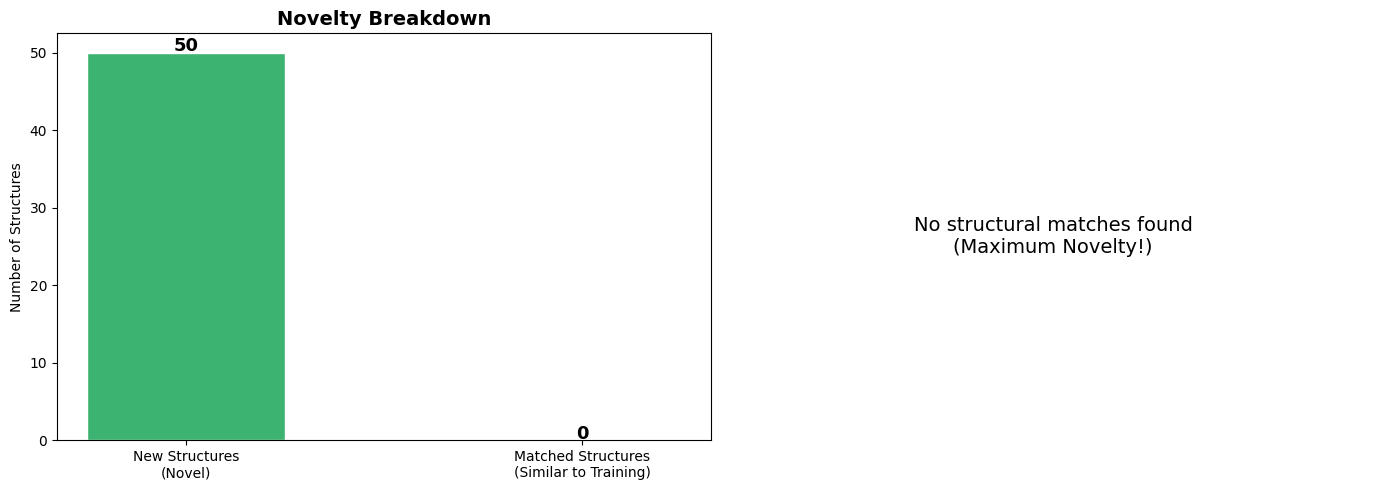


📊 Structural Dissimilarity Results:
   Total Generated       : 50
   Matched to Training   : 0
   Novel (New) Structures: 50  (100.0%)

💡 High novelty % = the QGAN is generating truly new crystal configurations, not memorizing training data.


In [16]:
if PYMATGEN_OK:
    ref_structs = [AseAtomsAdaptor.get_structure(a) for a in real_atoms_list]
    gen_structs = [AseAtomsAdaptor.get_structure(a) for a in generated_atoms]

    matcher = StructureMatcher(ltol=0.2, stol=0.3, angle_tol=5)
    match_count = 0
    rms_displacements = []

    for g_struct in gen_structs:
        best_rms = float('inf')
        is_match = False
        for ref in ref_structs:
            try:
                if matcher.fit(g_struct, ref):
                    is_match = True
                    rms = matcher.get_rms_dist(g_struct, ref)
                    if rms and rms[0] < best_rms:
                        best_rms = rms[0]
            except Exception:
                continue
        if is_match:
            match_count += 1
            rms_displacements.append(best_rms)

    novelty_pct = 100 * (len(gen_structs) - match_count) / len(gen_structs)

    # ── Plot ─────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    labels_bar = ['New Structures\n(Novel)', 'Matched Structures\n(Similar to Training)']
    counts_bar = [len(gen_structs) - match_count, match_count]
    colors_bar = ['mediumseagreen', 'tomato']
    axes[0].bar(labels_bar, counts_bar, color=colors_bar, edgecolor='white', width=0.5)
    axes[0].set_title('Novelty Breakdown', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Number of Structures')
    for i, v in enumerate(counts_bar):
        axes[0].text(i, v + 0.2, str(v), ha='center', fontweight='bold', fontsize=13)

    if rms_displacements:
        axes[1].hist(rms_displacements, bins=10, color='sandybrown', edgecolor='white', alpha=0.85)
        axes[1].set_title('RMS Displacement of Matched Structures', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('RMS Displacement (Å)')
        axes[1].set_ylabel('Count')
    else:
        axes[1].text(0.5, 0.5, 'No structural matches found\n(Maximum Novelty!)',
                     ha='center', va='center', transform=axes[1].transAxes, fontsize=14)
        axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    print(f"\n📊 Structural Dissimilarity Results:")
    print(f"   Total Generated       : {len(gen_structs)}")
    print(f"   Matched to Training   : {match_count}")
    print(f"   Novel (New) Structures: {len(gen_structs) - match_count}  ({novelty_pct:.1f}%)")
    if rms_displacements:
        print(f"   Avg RMS Displacement  : {np.mean(rms_displacements):.5f} Å")
    print("\n💡 High novelty % = the QGAN is generating truly new crystal configurations, not memorizing training data.")
else:
    print("StructureMatcher skipped — install pymatgen to enable this metric.")

## 4. Energy Above the Convex Hull (E_hull) — Requires MP API Key
**What it is:** This metric uses **CHGNet** (a universal machine learning force field) to relax the 3D crystal structure (minimize its energy), then queries the **Materials Project** for the Mg-Mn-O phase diagram to compute how far above the convex hull the structure sits.

**How to read the result:**
| E_hull | Meaning |
|--------|---------|
| `0 meV/atom` | Thermodynamically stable — already on the convex hull |
| `≤ 80 meV/atom` | **Potentially synthesizable** |
| `≤ 200 meV/atom` | **Theoretically metastable** |
| `> 200 meV/atom` | Thermodynamically unstable |

**To enable:** Set your free Materials Project API key: `$env:MP_API_KEY = "your_key_here"`

In [17]:
MP_API_KEY = os.environ.get('MP_API_KEY', 'hDXXoVT3jdqAXiIan4F9QK9J1Bc7gAGA')

if EHULL_OK and MP_API_KEY and PYMATGEN_OK:
    from pymatgen.entries.computed_entries import ComputedEntry
    
    print("Initializing CHGNet relaxer...")
    relaxer = StructOptimizer()
    
    print("Fetching Mg-Mn-O phase diagram from Materials Project...")
    with MPRester(MP_API_KEY) as mpr:
        entries = mpr.get_entries_in_chemsys(["Mg", "Mn", "O"])
    pd_obj = PhaseDiagram(entries)
    
    ehull_results = []
    N_EHULL = min(10, len(gen_structs))  # Relaxing structures is slow — limit to 10
    print(f"Relaxing {N_EHULL} structures with CHGNet (this may take a few minutes)...")
    
    for i, struct in enumerate(gen_structs[:N_EHULL]):
        try:
            result = relaxer.relax(struct, verbose=False)
            relaxed = result["final_structure"]
            energy_per_atom = result["trajectory"].energies[-1] / len(relaxed)
            entry = ComputedEntry(relaxed.composition, energy_per_atom * relaxed.composition.num_atoms)
            ehull = pd_obj.get_e_above_hull(entry)
            ehull_results.append(ehull)
            print(f"  Structure {i+1}: E_hull = {ehull*1000:.1f} meV/atom")
        except Exception as e:
            print(f"  Structure {i+1}: Error — {e}")
    
    if ehull_results:
        ehull_meV = [e * 1000 for e in ehull_results]
        metastable = sum(1 for e in ehull_meV if e <= 200)
        synthesizable = sum(1 for e in ehull_meV if e <= 80)
        
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.bar(range(len(ehull_meV)), ehull_meV,
               color=['mediumseagreen' if e <= 80 else 'gold' if e <= 200 else 'tomato' for e in ehull_meV])
        ax.axhline(80, color='blue', linestyle='--', label='Synthesizable threshold (80 meV/atom)')
        ax.axhline(200, color='red', linestyle='--', label='Metastable threshold (200 meV/atom)')
        ax.set_title('Energy Above Convex Hull per Generated Crystal', fontsize=14, fontweight='bold')
        ax.set_xlabel('Crystal Index')
        ax.set_ylabel('E_hull (meV/atom)')
        ax.legend()
        plt.tight_layout()
        plt.show()
        
        print(f"\n📊 E_hull Results:")
        print(f"   Relaxed Successfully    : {len(ehull_results)}")
        print(f"   Potentially Synthesizable (≤ 80 meV/atom) : {synthesizable}")
        print(f"   Theoretically Metastable (≤ 200 meV/atom) : {metastable}")
        print(f"   Average E_hull          : {np.mean(ehull_meV):.1f} meV/atom")
else:
    print("⚠️  E_hull skipped.")
    if not MP_API_KEY:
        print("   → Set your API key: $env:MP_API_KEY = 'your_key_here'")
        print("   → Get a free key at: https://next.materialsproject.org/api")
    if not EHULL_OK:
        print("   → Install dependencies: pip install chgnet mp-api")

NameError: name 'hDXXoVT3jdqAXiIan4F9QK9J1Bc7gAGA' is not defined

## 5. Training Loss Curve Over Epochs
**What it shows:** How the Generator Loss (WGAN + Physics), the Critic Loss, and the Physics Penalty changed during training.

**How to read it:**
- **Critic Loss** should stay roughly stable or very slowly improve — if it dives to 0 quickly, the Critic dominated too fast
- **Generator WGAN Loss** should gradually decrease toward 0 as the Generator gets better at fooling the Critic
- **Physics Penalty** should quickly drop to near 0, confirming the Generator learned the atomic distance rule early in training

> **Note:** The `training_loss_history.csv` is generated by `train_crystal.py` after training. If it does not exist, retrain the model — the CSV will be saved automatically.

⚠️  No training_loss_history.csv found.
   The model was trained before loss logging was added to train_crystal.py.
   Showing available checkpoint epochs as a timeline instead:



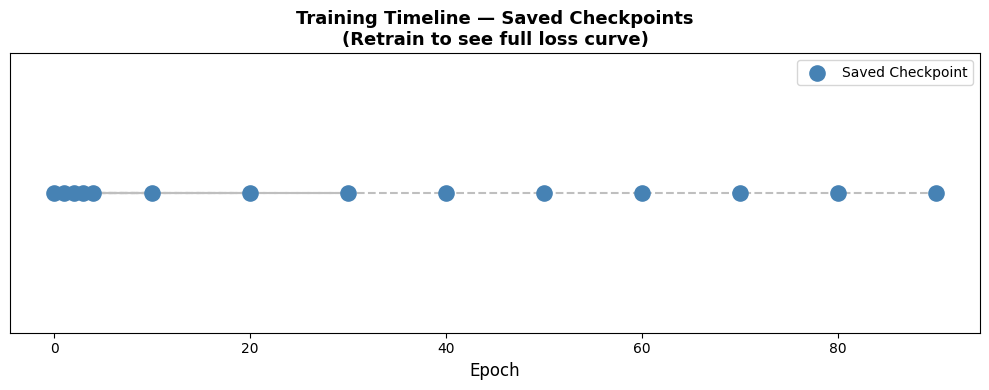


To generate the full loss curve, retrain the model:
   py -3.12 train_crystal.py --n_epochs 100
   Loss history will be auto-saved to results_crystal_qgan/training_loss_history.csv


In [ ]:
CSV_PATH = "results_crystal_qgan/training_loss_history.csv"

if os.path.exists(CSV_PATH):
    import pandas as pd
    df = pd.read_csv(CSV_PATH)
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle("QINR-QGAN Training Loss Over Epochs", fontsize=16, fontweight='bold')
    
    # Critic Loss
    axes[0,0].plot(df['epoch'], df['d_loss'], color='tomato', linewidth=2)
    axes[0,0].set_title('Critic (Discriminator) Loss', fontweight='bold')
    axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('Loss'); axes[0,0].grid(alpha=0.3)
    
    # Generator WGAN Loss
    axes[0,1].plot(df['epoch'], df['g_wgan_loss'], color='steelblue', linewidth=2)
    axes[0,1].set_title('Generator WGAN Loss', fontweight='bold')
    axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('Loss'); axes[0,1].grid(alpha=0.3)
    
    # Physics Penalty
    axes[1,0].plot(df['epoch'], df['physics_loss'], color='mediumseagreen', linewidth=2)
    axes[1,0].set_title('Physics Penalty (Distance)', fontweight='bold')
    axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('Penalty'); axes[1,0].grid(alpha=0.3)
    
    # Total Generator Loss
    axes[1,1].plot(df['epoch'], df['total_g_loss'], color='mediumpurple', linewidth=2)
    axes[1,1].set_title('Total Generator Loss (WGAN + Physics)', fontweight='bold')
    axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('Loss'); axes[1,1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"📊 Training Summary:")
    print(f"   Total Epochs          : {df['epoch'].max()}")
    print(f"   Final Critic Loss     : {df['d_loss'].iloc[-1]:.4f}")
    print(f"   Final Generator Loss  : {df['total_g_loss'].iloc[-1]:.4f}")
    print(f"   Final Physics Penalty : {df['physics_loss'].iloc[-1]:.4f}")
else:
    # ── Checkpoint-based proxy loss curve ─────────────────────────
    print("⚠️  No training_loss_history.csv found.")
    print("   The model was trained before loss logging was added to train_crystal.py.")
    print("   Showing available checkpoint epochs as a timeline instead:\n")
    
    ckpts = sorted(glob.glob("./results_crystal_qgan/checkpoint_*.pt"))
    ckpt_epochs = []
    for c in ckpts:
        try:
            ep = int(os.path.basename(c).replace("checkpoint_","").replace(".pt",""))
            ckpt_epochs.append(ep)
        except: pass
    
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.scatter(ckpt_epochs, [1]*len(ckpt_epochs), zorder=5, s=120, color='steelblue', label='Saved Checkpoint')
    ax.plot(ckpt_epochs, [1]*len(ckpt_epochs), linestyle='--', color='gray', alpha=0.5)
    ax.set_yticks([])
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_title('Training Timeline — Saved Checkpoints\n(Retrain to see full loss curve)', fontsize=13, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    print("\nTo generate the full loss curve, retrain the model:")
    print("   py -3.12 train_crystal.py --n_epochs 100")
    print("   Loss history will be auto-saved to results_crystal_qgan/training_loss_history.csv")